# Fig. 3(c,d,e,f)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import csv
from scipy import stats
from matplotlib.gridspec import GridSpec
from matplotlib.path import Path
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import scienceplots
from matplotlib.patches import Patch, Rectangle
from scipy.stats import norm

plt.style.use(['science', 'nature', 'no-latex'])

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans"], 
    "font.size": 20,
    "axes.labelsize": 24,
    "axes.titlesize": 24,
    "legend.fontsize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "axes.linewidth": 1.5,
})


# -----------------------------
# CONFIG
# -----------------------------
RESULTS_DIR = '../results/DSI/side_separated/'
FRI_CSV_FILE = '../results/FRI/FRI_all_neurons_per_neuron_baseline.csv'

SIDES = ['right', 'left']

CSV_FILES = {
    'left': {
        'D2L': os.path.join(RESULTS_DIR, 'DSI_OFF_left.csv'),
        'L2D': os.path.join(RESULTS_DIR, 'DSI_ON_left.csv'),
    },
    'right': {
        'D2L': os.path.join(RESULTS_DIR, 'DSI_OFF_right.csv'),
        'L2D': os.path.join(RESULTS_DIR, 'DSI_ON_right.csv'),
    }
}

# Visualization parameters
SPACING = 1.2
MAX_DENSITY_WIDTH = 0.18
FRI_DENSITY_WIDTH = 0.24
Y_GRID_POINTS = 400
PAGE_SIZE = 25

# Colors
ON_COLOR = '#F15D4D'
OFF_COLOR = '#5F9ECA'
GRAY_COLOR = '#A9A9A9'
PRIORITY_COLOR = '#5F9ECA'
AX_FACECOLOR = '#FFFFFF'


# -----------------------------
# DATA UTILITIES
# -----------------------------
def ensure_dirs():
    os.makedirs(RESULTS_DIR, exist_ok=True)


def compute_median(values):
    values = np.asarray(values, dtype=float)
    return float(np.median(values))


def read_fri_csv(csv_file=FRI_CSV_FILE):
    types_fri = {}
    with open(csv_file, 'r', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            t = row['type']
            v = float(row['fri'])
            types_fri.setdefault(t, []).append(v)
    return types_fri


def read_csv_with_angle(csv_path):
    data_dsi = {}
    data_angle = {}
    encodings = ['utf-8', 'utf-8-sig', 'gbk', 'ansi', 'latin1']

    for enc in encodings:
        try:
            with open(csv_path, 'r', encoding=enc, newline='') as f:
                reader = csv.DictReader(f)
                for row in reader:
                    t = row['type']
                    try:
                        v = float(row['DSI'])
                        a = float(row.get('PreferredAngle', -1))
                    except Exception:
                        continue

                    v = max(0.0, min(1.0, v))

                    data_dsi.setdefault(t, []).append(v)
                    data_angle.setdefault(t, []).append(a)

            return data_dsi, data_angle

        except UnicodeDecodeError:
            continue

    raise UnicodeDecodeError(f'{csv_path}')


def safe_normal_density(vals, y_grid):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.zeros_like(y_grid)

    mu = np.mean(vals)

    if len(vals) < 2:
        sigma = 0.03
    else:
        sigma = np.std(vals, ddof=1)

    sigma = max(float(sigma), 0.03)

    density = norm.pdf(y_grid, loc=mu, scale=sigma)

    if np.max(density) > 0:
        density = density / np.max(density)
    else:
        return np.zeros_like(y_grid)

    return density


def safe_angle_normal_density(vals_angle_deg, y_grid_angle_deg):
    vals = np.asarray(vals_angle_deg, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals >= 0]

    y_grid_angle_deg = np.asarray(y_grid_angle_deg, dtype=float)

    if len(vals) == 0:
        return np.zeros_like(y_grid_angle_deg)

    vals = vals % 360.0

    if len(vals) < 2 or np.allclose(vals.std(), 0.0):
        center = float(vals[0])
        sigma = 3.0
        density = np.exp(
            -0.5 * ((y_grid_angle_deg - center) / sigma) ** 2
        )
    else:
        kde = stats.gaussian_kde(vals)
        density = kde(y_grid_angle_deg)

    if np.max(density) == 0:
        return np.zeros_like(y_grid_angle_deg)

    density = density / np.max(density)

    return density


def angle_bin_count_and_sum_dsi(ang_vals_deg, dsi_vals, step=20):
    bins = np.deg2rad(np.arange(0, 360 + step, step))
    bin_centers = (bins[:-1] + bins[1:]) / 2

    if len(ang_vals_deg) == 0:
        return np.zeros_like(bin_centers), np.zeros_like(bin_centers), bin_centers

    ang_vals = np.deg2rad(np.asarray(ang_vals_deg, dtype=float) % 360)
    dsi_vals = np.asarray(dsi_vals, dtype=float)

    counts = np.zeros_like(bin_centers)
    sum_dsi = np.zeros_like(bin_centers)

    for j in range(len(bins) - 1):
        mask = (ang_vals >= bins[j]) & (ang_vals < bins[j + 1])
        counts[j] = np.sum(mask)
        sum_dsi[j] = np.sum(dsi_vals[mask])

    counts = np.append(counts, counts[0])
    sum_dsi = np.append(sum_dsi, sum_dsi[0])
    bin_centers = np.append(bin_centers, bin_centers[0])

    return counts, sum_dsi, bin_centers


def safe_max(values, default=1.0):
    vals = [float(v) for v in values if np.isfinite(v)]

    if len(vals) == 0:
        return default

    m = max(vals)

    return m if m > 0 else default


# -------------------------------
# VISUALIZATION UTILITIES
# -------------------------------
def sharp_triangle_marker(rotation_deg=0):
    verts = np.array([
        [0.0, 0.0],
        [-0.2, -0.5],
        [0.2, -0.5],
        [0.0, 0.0]
    ])

    theta = np.deg2rad(rotation_deg)

    rot = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    return Path(verts @ rot.T)


def format_axis(ax, labelbottom=False):
    ax.set_facecolor(AX_FACECOLOR)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(1.5)

    ax.tick_params(
        axis='both',
        which='major',
        direction='out',
        length=6,
        width=1.5,
        top=False,
        right=False,
        labelbottom=labelbottom
    )

    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')


def get_continuous_runs(sub_types, target_set):
    """
    Find continuous index runs for types belonging to target_set.
    Example:
    [A, B, C, D], target={B,C} -> [(1,2)]
    """
    runs = []
    start = None

    for i, t in enumerate(sub_types):
        if t in target_set:
            if start is None:
                start = i
        else:
            if start is not None:
                runs.append((start, i - 1))
                start = None

    if start is not None:
        runs.append((start, len(sub_types) - 1))

    return runs


def draw_group_label_boxes(
    ax,
    sub_types,
    x,
    group_specs,
    y_bottom=-0.42,
    y_top=-0.02,
    lw=2.0
):
    """
    Draw continuous boxes around rotated x labels.

    Parameters
    ----------
    ax : matplotlib axis
    sub_types : list[str]
    x : x positions in data coordinates
    group_specs : list of (target_set, edge_color)
    y_bottom, y_top : in x-axis transform coordinates
    """
    trans = ax.get_xaxis_transform()

    for target_set, edge_color in group_specs:
        runs = get_continuous_runs(sub_types, target_set)

        for start, end in runs:
            x0 = x[start] - SPACING * 0.42
            x1 = x[end] + SPACING * 0.30

            rect = Rectangle(
                (x0, y_bottom),
                x1 - x0,
                y_top - y_bottom,
                transform=trans,
                facecolor='none',
                edgecolor=edge_color,
                linewidth=lw,
                clip_on=False,
                zorder=20
            )

            ax.add_patch(rect)


def add_vertical_type_labels(
    ax,
    sub_types,
    x,
    y=-0.05,
    fontsize=None,
    label_color_func=None,
    label_bbox_func=None
):
    """
    Add rotated type labels below x-axis.

    label_color_func(t) -> text color
    label_bbox_func(t)  -> bbox dict or None
    """
    for i, t in enumerate(sub_types):
        color = label_color_func(t) if label_color_func is not None else 'black'
        bbox = label_bbox_func(t) if label_bbox_func is not None else None

        ax.text(
            x[i],
            y,
            t,
            transform=ax.get_xaxis_transform(),
            rotation=90,
            ha='center',
            va='top',
            color=color,
            fontweight='normal',
            fontsize=fontsize,
            bbox=bbox,
            clip_on=False,
            zorder=30
        )


def onoff_label_color(t, group_on, group_off):
    """
    Return label text color according to ON/OFF group.
    """
    if t in group_on:
        return ON_COLOR
    if t in group_off:
        return OFF_COLOR
    return 'black'


def t4t5_single_label_bbox(t, group_t4, group_t5):
    """
    Draw one small box for each T4/T5 label, instead of a continuous large group box.
    """
    if t in group_t4:
        return dict(
            facecolor='none',
            edgecolor=ON_COLOR,
            linewidth=1.8,
            boxstyle='round,pad=0.16'
        )

    if t in group_t5:
        return dict(
            facecolor='none',
            edgecolor=OFF_COLOR,
            linewidth=1.8,
            boxstyle='round,pad=0.16'
        )

    return None


# -------------------------------
# MAIN PLOT
# -------------------------------
def plot_combined_fri_dsi():
    ensure_dirs()

    types_fri = read_fri_csv(FRI_CSV_FILE)

    group_on = {
        'L5', 'C3', 'Mi1', 'Mi4',
        'T4a', 'T4b', 'T4c', 'T4d',
        'Tm3'
    }

    group_off = {
        'L1', 'L2', 'L3', 'L4',
        'Mi9',
        'T5a', 'T5b', 'T5c', 'T5d',
        'Tm1', 'Tm2', 'Tm4', 'Tm9',
        'Dm3p', 'Dm3q', 'Dm3v'
    }

    group_t4 = {'T4a', 'T4b', 'T4c', 'T4d'}
    group_t5 = {'T5a', 'T5b', 'T5c', 'T5d'}

    legend_handles = [
        Patch(
            facecolor=ON_COLOR,
            edgecolor='none',
            alpha=0.95,
            label='ON-contrast selective'
        ),
        Patch(
            facecolor=OFF_COLOR,
            alpha=0.95,
            edgecolor='none',
            label='OFF-contrast selective'
        ),
    ]

    onoff_handles = [
        Patch(
            facecolor=ON_COLOR,
            edgecolor='none',
            alpha=0.95,
            label='ON-edge motion'
        ),
        Patch(
            facecolor=OFF_COLOR,
            edgecolor='none',
            alpha=0.95,
            label='OFF-edge motion'
        ),
    ]

    for side in SIDES:
        d2l_dsi, d2l_angle = read_csv_with_angle(CSV_FILES[side]['D2L'])
        l2d_dsi, l2d_angle = read_csv_with_angle(CSV_FILES[side]['L2D'])

        all_types = sorted(
            set(types_fri.keys()) |
            set(d2l_dsi.keys()) |
            set(l2d_dsi.keys())
        )

        priority = [
            'C3', 'L5', 'Mi1', 'Mi4',
            'T4a', 'T4b', 'T4c', 'T4d',
            'Tm3',
            'L1', 'L2', 'L3', 'L4',
            'Mi9',
            'T5a', 'T5b', 'T5c', 'T5d',
            'Tm1', 'Tm2', 'Tm4', 'Tm9',
            'Dm3p', 'Dm3q', 'Dm3v'
        ]

        sorted_types = (
            [t for t in priority if t in all_types] +
            [t for t in all_types if t not in priority]
        )

        filtered_types = [
            t for t in sorted_types
            if len(types_fri.get(t, [])) >= 10
            or len(d2l_dsi.get(t, [])) >= 10
            or len(l2d_dsi.get(t, [])) >= 10
        ]

        n_types = len(filtered_types)
        n_pages = (n_types + PAGE_SIZE - 1) // PAGE_SIZE

        for page in range(n_pages):
            start = page * PAGE_SIZE
            end = min((page + 1) * PAGE_SIZE, n_types)

            sub_types = filtered_types[start:end]
            x = np.arange(len(sub_types), dtype=float) * SPACING

            fig_w = max(12, len(sub_types) * SPACING)
            fig_h = 16

            fig = plt.figure(figsize=(fig_w, fig_h), facecolor='white')

            gs = GridSpec(
                4,
                1,
                figure=fig,
                height_ratios=[1, 1, 1, 1],
                hspace=0.55
            )

            # ----------------------------
            # 1. FRI KDE
            # ----------------------------
            ax_fri = fig.add_subplot(gs[0, 0])
            format_axis(ax_fri, labelbottom=True)

            y_grid_fri = np.linspace(-1, 1, Y_GRID_POINTS)

            for i, t in enumerate(sub_types):
                vals = np.asarray(types_fri.get(t, []), dtype=float)

                if len(vals) < 10:
                    continue

                density = safe_normal_density(vals, y_grid_fri)
                width = FRI_DENSITY_WIDTH * density

                if t in group_on:
                    fill_color = ON_COLOR
                elif t in group_off:
                    fill_color = OFF_COLOR
                else:
                    fill_color = GRAY_COLOR

                median_line_color = '#2F2F2F'

                ax_fri.fill_betweenx(
                    y_grid_fri,
                    x[i] - width,
                    x[i] + width,
                    facecolor=fill_color,
                    alpha=0.95,
                    edgecolor='none',
                    zorder=2
                )

                median = compute_median(vals)

                ax_fri.plot(
                    [x[i] - 0.14, x[i] + 0.14],
                    [median, median],
                    color=median_line_color,
                    lw=2.5,
                    zorder=4
                )

            ax_fri.axhline(0, color='gray', ls='--', lw=0.8)
            ax_fri.set_ylabel('FRI')
            ax_fri.set_ylim(-1.0, 1.0)
            ax_fri.set_yticks(np.arange(-1.0, 1.01, 0.5))

            ax_fri.legend(
                handles=legend_handles,
                loc='upper right',
                frameon=False,
                handlelength=2.2,
                fontsize=24,
                ncol=2
            )

            ax_fri.set_xticks(x)
            ax_fri.set_xticklabels([])

            add_vertical_type_labels(
                ax_fri,
                sub_types,
                x,
                y=-0.05,
                label_color_func=lambda tt: onoff_label_color(
                    tt,
                    group_on,
                    group_off
                )
            )

            # ----------------------------
            # 2. DSI KDE
            # ----------------------------
            ax = fig.add_subplot(gs[1, 0], sharex=ax_fri)
            format_axis(ax, labelbottom=True)

            ax.set_ylim(-1.0, 1.0)

            yticks = np.arange(-1.0, 1.01, 0.5)
            ax.set_yticks(yticks)
            ax.set_yticklabels([f'{abs(v):.1f}' for v in yticks])

            ax.axhline(0, color='gray', ls='--', lw=0.8)
            ax.set_ylabel('DSI')

            y_grid = np.linspace(0.0, 1.0, Y_GRID_POINTS)

            for i, t in enumerate(sub_types):
                vals_on = np.asarray(l2d_dsi.get(t, []), dtype=float)
                vals_off = np.asarray(d2l_dsi.get(t, []), dtype=float)

                if len(vals_on) >= 10:
                    density = safe_normal_density(vals_on, y_grid)
                    width = MAX_DENSITY_WIDTH * density

                    ax.fill_betweenx(
                        y_grid,
                        x[i] - width,
                        x[i] + width,
                        facecolor=ON_COLOR,
                        alpha=0.95,
                        edgecolor='none',
                        zorder=2
                    )

                    median = compute_median(vals_on)

                    ax.plot(
                        [x[i] - 0.12, x[i] + 0.12],
                        [median, median],
                        color='#2F2F2F',
                        lw=2.4,
                        zorder=4
                    )

                if len(vals_off) >= 10:
                    density = safe_normal_density(vals_off, y_grid)
                    width = MAX_DENSITY_WIDTH * density

                    ax.fill_betweenx(
                        -y_grid,
                        x[i] - width,
                        x[i] + width,
                        facecolor=OFF_COLOR,
                        alpha=0.95,
                        edgecolor='none',
                        zorder=2
                    )

                    median = compute_median(vals_off)

                    ax.plot(
                        [x[i] - 0.12, x[i] + 0.12],
                        [-median, -median],
                        color='#2F2F2F',
                        lw=2.4,
                        zorder=4
                    )

            ax.legend(
                handles=onoff_handles,
                loc='upper right',
                bbox_to_anchor=(1.04, 1.08),
                frameon=False,
                handlelength=2.2,
                fontsize=24,
                ncol=2
            )

            ax.set_xticks(x)
            ax.set_xticklabels([])

            add_vertical_type_labels(
                ax,
                sub_types,
                x,
                y=-0.05,
                label_bbox_func=lambda tt: t4t5_single_label_bbox(
                    tt,
                    group_t4,
                    group_t5
                )
            )

            # ----------------------------
            # 3. PreferredAngle KDE
            # ----------------------------
            ax2 = fig.add_subplot(gs[2, 0], sharex=ax_fri)
            format_axis(ax2, labelbottom=True)

            ax2.set_ylim(-360, 360)

            angle_ticks = np.arange(-360, 361, 180)
            ax2.set_yticks(angle_ticks)
            ax2.set_yticklabels([f'{abs(v):.0f}' for v in angle_ticks])

            ax2.axhline(0, color='gray', ls='--', lw=0.8)
            ax2.set_ylabel('PD (°)')
            ax2.set_xlabel('')

            y_grid_angle = np.linspace(0, 360, Y_GRID_POINTS)

            for i, t in enumerate(sub_types):
                vals_angle_on = np.asarray(
                    [v for v in l2d_angle.get(t, []) if v >= 0],
                    dtype=float
                )

                vals_angle_off = np.asarray(
                    [v for v in d2l_angle.get(t, []) if v >= 0],
                    dtype=float
                )

                n_on_total = max(len(l2d_dsi.get(t, [])), 1)
                n_off_total = max(len(d2l_dsi.get(t, [])), 1)

                if len(vals_angle_on) >= 10:
                    norm_width = max(len(vals_angle_on) / n_on_total, 0.01)
                    density = safe_angle_normal_density(vals_angle_on, y_grid_angle)
                    width = MAX_DENSITY_WIDTH * density * norm_width
                    line_length = 2 * MAX_DENSITY_WIDTH * norm_width

                    if line_length > 0.036:
                        ax2.fill_betweenx(
                            y_grid_angle,
                            x[i] - width,
                            x[i] + width,
                            facecolor=ON_COLOR,
                            alpha=0.95,
                            edgecolor='none',
                            zorder=2
                        )

                        max_idx = int(np.argmax(density))

                        ax2.plot(
                            [
                                x[i] - MAX_DENSITY_WIDTH * norm_width,
                                x[i] + MAX_DENSITY_WIDTH * norm_width
                            ],
                            [y_grid_angle[max_idx], y_grid_angle[max_idx]],
                            color='#2F2F2F',
                            lw=2.4,
                            zorder=3
                        )

                if len(vals_angle_off) >= 10:
                    norm_width = max(len(vals_angle_off) / n_off_total, 0.01)
                    density = safe_angle_normal_density(vals_angle_off, y_grid_angle)
                    width = MAX_DENSITY_WIDTH * density * norm_width
                    line_length = 2 * MAX_DENSITY_WIDTH * norm_width

                    if line_length > 0.036:
                        ax2.fill_betweenx(
                            -y_grid_angle,
                            x[i] - width,
                            x[i] + width,
                            facecolor=OFF_COLOR,
                            alpha=0.95,
                            edgecolor='none',
                            zorder=2
                        )

                        max_idx = int(np.argmax(density))

                        ax2.plot(
                            [
                                x[i] - MAX_DENSITY_WIDTH * norm_width,
                                x[i] + MAX_DENSITY_WIDTH * norm_width
                            ],
                            [-y_grid_angle[max_idx], -y_grid_angle[max_idx]],
                            color='#2F2F2F',
                            lw=2.4,
                            zorder=3
                        )

            ax2.legend(
                handles=onoff_handles,
                loc='upper right',
                bbox_to_anchor=(1.04, 1.08),
                frameon=False,
                handlelength=2.2,
                fontsize=24,
                ncol=2
            )

            ax2.set_xticks(x)
            ax2.set_xticklabels([])

            add_vertical_type_labels(
                ax2,
                sub_types,
                x,
                y=-0.05,
                label_bbox_func=lambda tt: t4t5_single_label_bbox(
                    tt,
                    group_t4,
                    group_t5
                )
            )

            for a in [ax_fri, ax, ax2]:
                a.yaxis.set_label_coords(-0.03, 0.5)

            # ----------------------------
            # 4. Radar per type
            # ----------------------------
            n_radar_rows = 2

            gs_radar = GridSpec(
                n_radar_rows,
                len(sub_types) + 1,
                figure=fig,
                top=0.29,
                bottom=0.05,
                left=0.15,
                right=0.903,
                hspace=0,
                wspace=0
            )

            angle_step = 20
            dsi_step = 0.1

            angle_bins = np.deg2rad(np.arange(0, 360 + angle_step, angle_step))
            dsi_bins = np.arange(0, 1 + dsi_step, dsi_step)

            hist_data = {}
            angle_bin_curves_on = {}
            angle_bin_curves_off = {}

            for t in sub_types:
                vals_angle_on = np.asarray(
                    [v for v in l2d_angle.get(t, []) if v >= 0],
                    dtype=float
                )

                vals_angle_off = np.asarray(
                    [v for v in d2l_angle.get(t, []) if v >= 0],
                    dtype=float
                )

                dsis_on = [
                    v for (v, a) in zip(
                        l2d_dsi.get(t, []),
                        l2d_angle.get(t, [])
                    )
                    if a >= 0
                ]

                dsis_off = [
                    v for (v, a) in zip(
                        d2l_dsi.get(t, []),
                        d2l_angle.get(t, [])
                    )
                    if a >= 0
                ]

                _, sum_dsi_on, bin_centers_on = angle_bin_count_and_sum_dsi(
                    vals_angle_on,
                    dsis_on,
                    step=angle_step
                )

                angle_bin_curves_on[t] = (sum_dsi_on, bin_centers_on)

                _, sum_dsi_off, bin_centers_off = angle_bin_count_and_sum_dsi(
                    vals_angle_off,
                    dsis_off,
                    step=angle_step
                )

                angle_bin_curves_off[t] = (sum_dsi_off, bin_centers_off)

                vals_on = np.asarray(l2d_dsi.get(t, []), dtype=float)
                angles_on = np.deg2rad(
                    np.asarray(l2d_angle.get(t, []), dtype=float) % 360
                )

                mask_on = (vals_on > 0) & np.isfinite(angles_on)

                H_on, _, _ = np.histogram2d(
                    angles_on[mask_on],
                    vals_on[mask_on],
                    bins=[angle_bins, dsi_bins]
                )

                hist_data[(t, 'on')] = H_on.T

                vals_off = np.asarray(d2l_dsi.get(t, []), dtype=float)
                angles_off = np.deg2rad(
                    np.asarray(d2l_angle.get(t, []), dtype=float) % 360
                )

                mask_off = (vals_off > 0) & np.isfinite(angles_off)

                H_off, _, _ = np.histogram2d(
                    angles_off[mask_off],
                    vals_off[mask_off],
                    bins=[angle_bins, dsi_bins]
                )

                hist_data[(t, 'off')] = H_off.T

            max_on_heatmap = safe_max(
                np.max(H)
                for (t, key), H in hist_data.items()
                if key == 'on'
            )

            max_off_heatmap = safe_max(
                np.max(H)
                for (t, key), H in hist_data.items()
                if key == 'off'
            )

            max_on_curve = safe_max(
                np.max(c[0])
                for c in angle_bin_curves_on.values()
            )

            max_off_curve = safe_max(
                np.max(c[0])
                for c in angle_bin_curves_off.values()
            )

            for i, t in enumerate(sub_types):
                ax_on = fig.add_subplot(gs_radar[0, i], polar=True)
                ax_off = fig.add_subplot(gs_radar[1, i], polar=True)

                H_on = hist_data[(t, 'on')] / max_on_heatmap

                for ai in range(H_on.shape[1]):
                    for di in range(H_on.shape[0]):
                        if H_on[di, ai] == 0:
                            continue

                        theta = (angle_bins[ai] + angle_bins[ai + 1]) / 2
                        width = angle_bins[ai + 1] - angle_bins[ai]
                        r = (dsi_bins[di] + dsi_bins[di + 1]) / 2
                        height = dsi_bins[di + 1] - dsi_bins[di]

                        ax_on.bar(
                            theta,
                            height,
                            width=width,
                            bottom=r - height / 2,
                            color=plt.cm.Reds(H_on[di, ai]),
                            edgecolor=None,
                            alpha=0.8
                        )

                curve_on, bin_centers_on = angle_bin_curves_on[t]

                ax_on.plot(
                    bin_centers_on,
                    curve_on / max_on_curve,
                    color=ON_COLOR,
                    lw=1.2,
                    zorder=10,
                    alpha=0.9
                )

                ax_on.set_xticks([])
                ax_on.set_yticks([])
                ax_on.set_ylim(0, 1)

                H_off = hist_data[(t, 'off')] / max_off_heatmap

                for ai in range(H_off.shape[1]):
                    for di in range(H_off.shape[0]):
                        if H_off[di, ai] == 0:
                            continue

                        theta = (angle_bins[ai] + angle_bins[ai + 1]) / 2
                        width = angle_bins[ai + 1] - angle_bins[ai]
                        r = (dsi_bins[di] + dsi_bins[di + 1]) / 2
                        height = dsi_bins[di + 1] - dsi_bins[di]

                        ax_off.bar(
                            theta,
                            height,
                            width=width,
                            bottom=r - height / 2,
                            color=plt.cm.Blues(H_off[di, ai]),
                            edgecolor=None,
                            alpha=0.8
                        )

                curve_off, bin_centers_off = angle_bin_curves_off[t]

                ax_off.plot(
                    bin_centers_off,
                    curve_off / max_off_curve,
                    color=OFF_COLOR,
                    lw=1.2,
                    zorder=10,
                    alpha=0.9
                )

                ax_off.set_xticks([])
                ax_off.set_yticks([])
                ax_off.set_ylim(0, 1)
            for a in [ax_fri, ax, ax2]:
                a.set_xlim(
                    x[0] - 1.7,
                    x[-1] +1.7
                )
            # -------------------------------------------
            # REFERENCE COORDINATES: Orientation Guide
            # -------------------------------------------
            ref_ax = fig.add_axes([0.1, 0.12, 0.04, 0.08], polar=True)

            ref_ax.set_theta_zero_location('N')
            ref_ax.set_theta_direction(-1)
            ref_ax.set_ylim(0, 1)
            ref_ax.set_yticks([])

            ref_ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
            ref_ax.set_xticklabels(
                ['90', '0', '270', '180'],
                fontsize=16
            )

            ref_ax.tick_params(pad=5)
            ref_ax.grid(True, linestyle='--', linewidth=1, alpha=0.95)

            for spine in ref_ax.spines.values():
                spine.set_visible(False)

            ref_ax.text(
                0,
                1.7,
                'Direction (°)',
                ha='center',
                va='center'
            )

            ref_ax.set_facecolor('lightgray')

            # -------------------------------------------
            # DSI arrow from center
            # -------------------------------------------
            theta_arrow = np.deg2rad(45)
            r0 = 0.0
            r1 = 0.75

            ref_ax.annotate(
                '',
                xy=(theta_arrow, r1),
                xytext=(theta_arrow, r0),
                arrowprops=dict(
                    arrowstyle='->',
                    lw=2.5,
                    color='black'
                )
            )

            ref_ax.text(
                theta_arrow,
                r1 + 0.12,
                'NTDSI',
                ha='center',
                va='center',
                fontsize=16,
                color='black'
            )

            cax_on = fig.add_axes([0.89, 0.20, 0.01, 0.06])
            sm_on = ScalarMappable(cmap='Reds', norm=plt.Normalize(0, 1))
            cbar_on = fig.colorbar(sm_on, cax=cax_on, orientation='vertical')

            cax_on.set_title(
                'ON',
                color="#000000",
                pad=6,
                fontsize=16
            )

            cbar_on.set_label(
                'RC',
                rotation=90,
                fontsize=24
            )

            cbar_on.ax.yaxis.set_label_coords(2, -0.5)
            cax_on.set_yticks([0, 1])
            cax_on.tick_params(axis='y', labelsize=16)
            cax_on.set_xticks([])

            cax_off = fig.add_axes([0.89, 0.08, 0.01, 0.06])
            sm_off = ScalarMappable(cmap='Blues', norm=plt.Normalize(0, 1))
            fig.colorbar(sm_off, cax=cax_off, orientation='vertical')

            cax_off.set_title(
                'OFF',
                color="#000000",
                pad=6,
                fontsize=16
            )

            cax_off.set_yticks([0, 1])
            cax_off.tick_params(axis='y', labelsize=16)
            cax_off.set_xticks([])

            out_path = os.path.join(
                RESULTS_DIR,
                f'{side}_combined_page_{page + 1}.png'
            )

            plt.savefig(out_path, dpi=600, bbox_inches='tight')
            plt.close(fig)

            print(f'✅ Saved page {page + 1} -> {out_path}')


if __name__ == '__main__':
    plot_combined_fri_dsi()

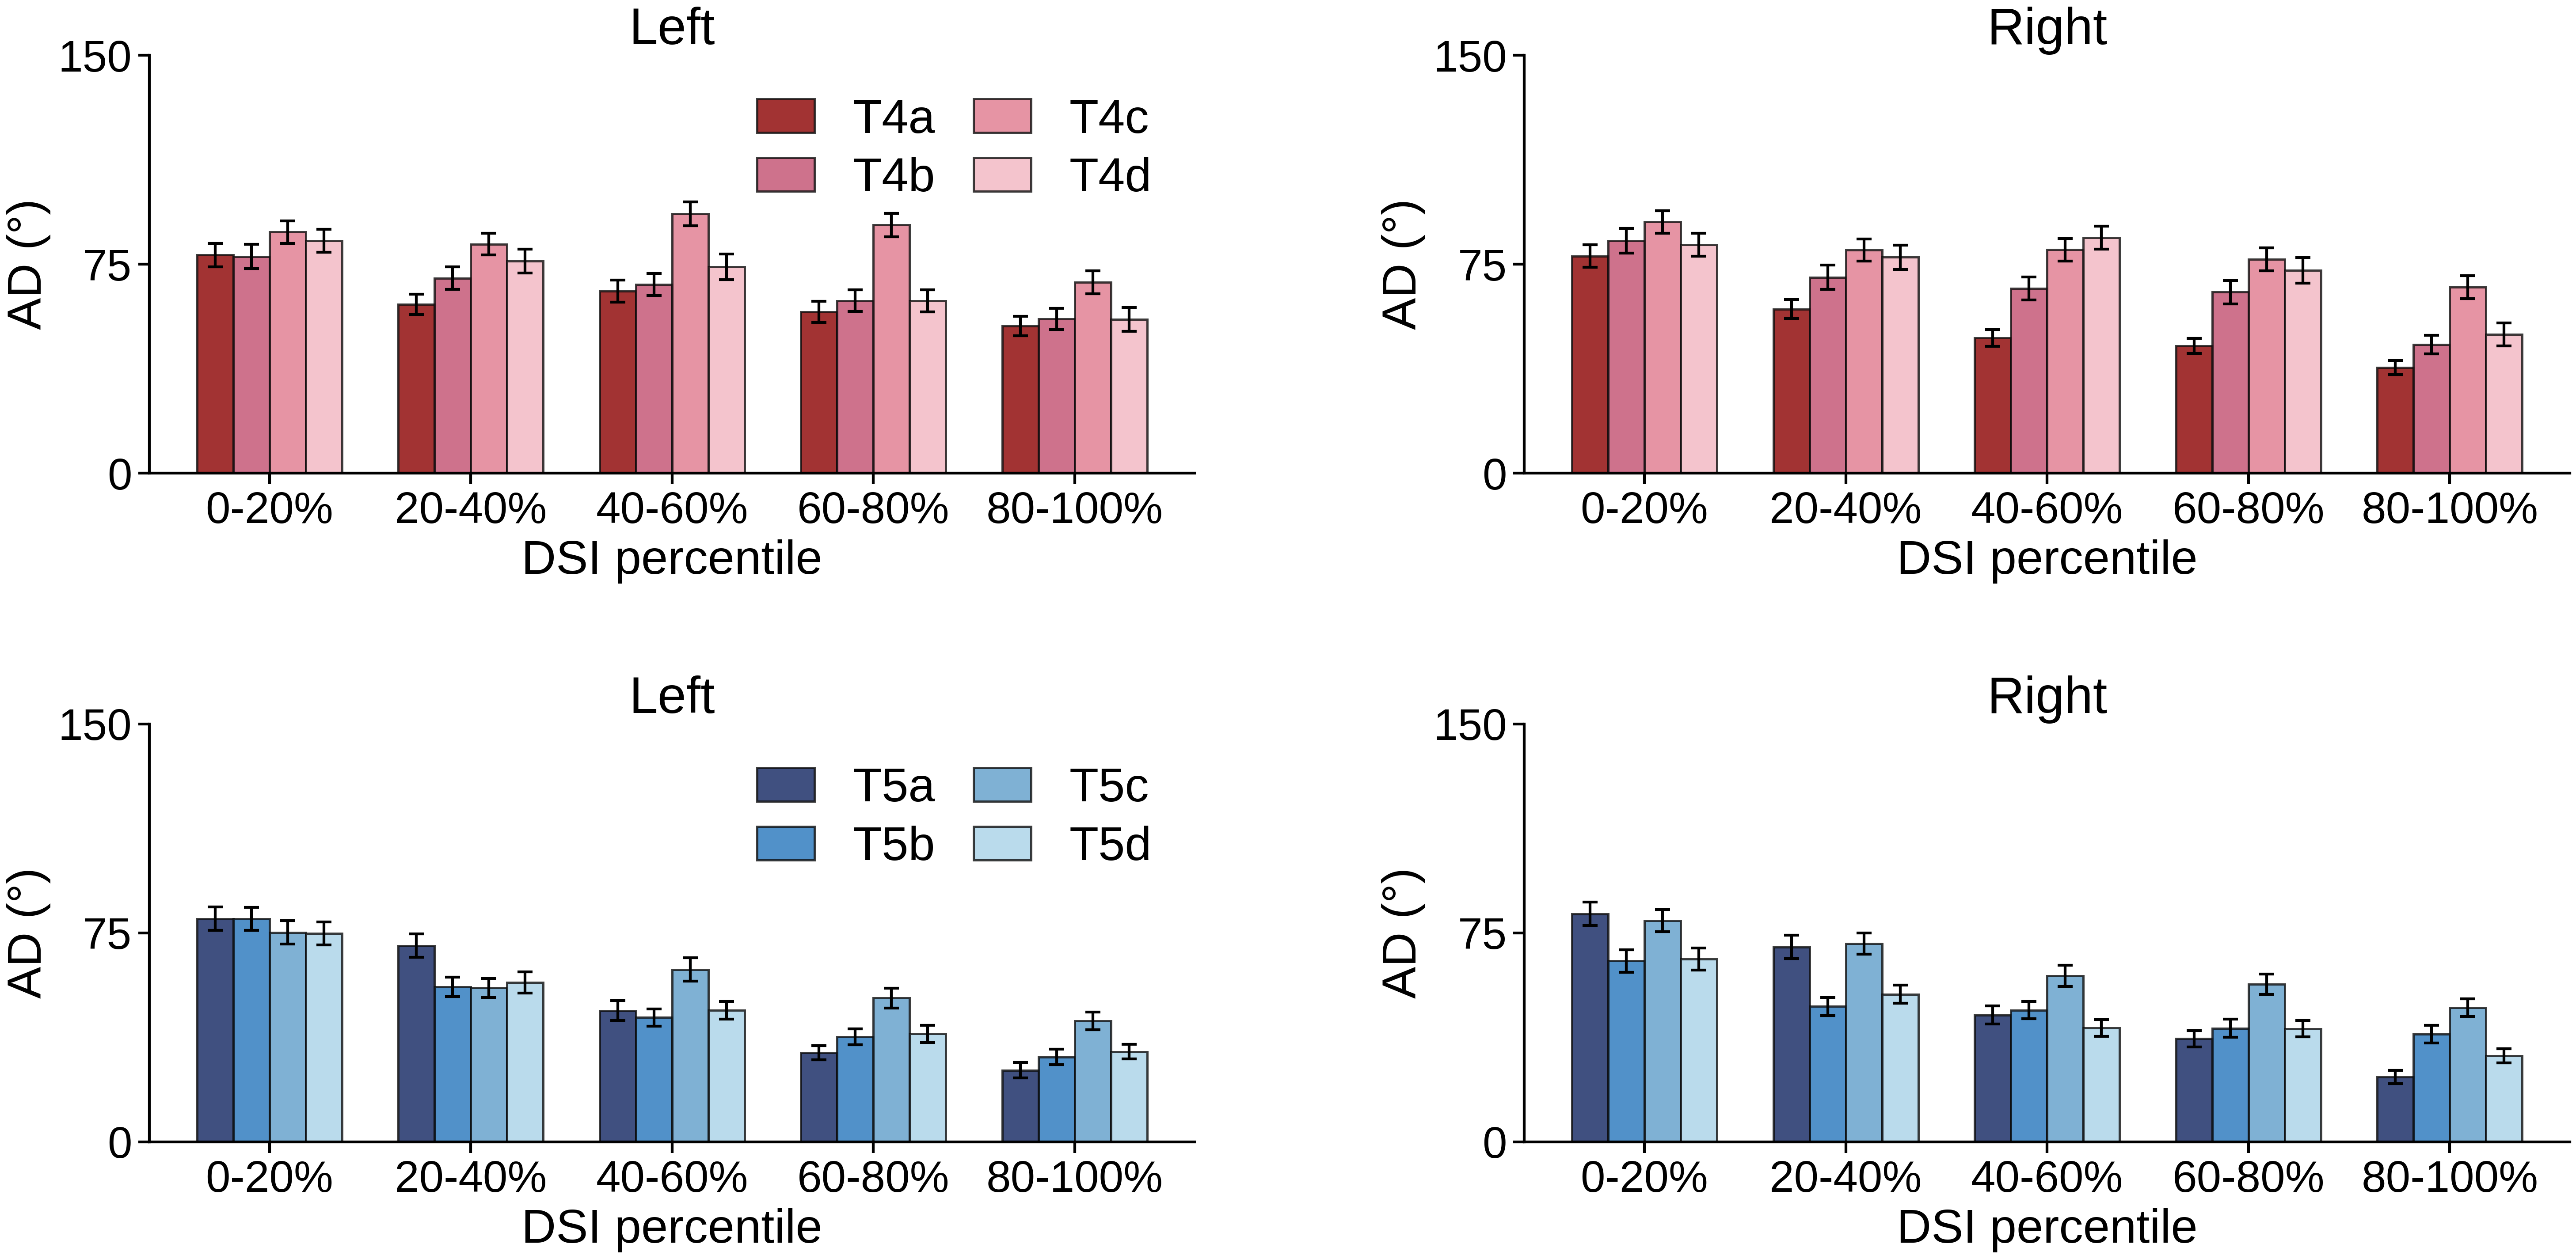

✅ Saved figure: ../results/DSI/AD_barplots_2x2_left_right/AD_barplot_T4_row_T5_row_left_right_0_150.png


In [ ]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'nature', 'no-latex'])

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans"],

    "font.size": 26,
    "axes.labelsize": 26,
    "axes.titlesize": 26,
    "legend.fontsize": 26,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,

    "axes.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 600,

    "xtick.top": False,
    "ytick.right": False,
    "xtick.minor.top": False,
    "ytick.minor.right": False,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

# ==========================
# Paths
# ==========================
RESULTS_DIR = '../results/DSI/AD_barplots_2x2_left_right/'
os.makedirs(RESULTS_DIR, exist_ok=True)

CSV_ON_LEFT   = '../results/DSI/side_separated/DSI_ON_left.csv'
CSV_OFF_LEFT  = '../results/DSI/side_separated/DSI_OFF_left.csv'
CSV_ON_RIGHT  = '../results/DSI/side_separated/DSI_ON_right.csv'
CSV_OFF_RIGHT = '../results/DSI/side_separated/DSI_OFF_right.csv'

# ==========================
# Types
# ==========================
T4_TYPES = ['T4a', 'T4b', 'T4c', 'T4d']
T5_TYPES = ['T5a', 'T5b', 'T5c', 'T5d']

# ==========================
# Target directions
# Left : 180, 0, 90, 270
# Right: 0, 180, 90, 270
# ==========================
T4_DIRS_LEFT  = [180, 0, 90, 270]
T5_DIRS_LEFT  = [180, 0, 90, 270]

T4_DIRS_RIGHT = [0, 180, 90, 270]
T5_DIRS_RIGHT = [0, 180, 90, 270]

# ==========================
# Colors
# ==========================
T4_COLORS = {
    'T4a': '#8B0000',
    'T4b': '#C24F70',
    'T4c': '#E07A8D',
    'T4d': '#F2B6C1',
}

T5_COLORS = {
    'T5a': '#102461',
    'T5b': '#2576BC',
    'T5c': '#5F9ECA',
    'T5d': '#A9D3E8',
}

PERCENTILE_STEP = 20


# ==========================
# Read CSV
# ==========================
def read_csv_data(csv_path, types):
    data = {t: [] for t in types}

    for enc in ['utf-8', 'utf-8-sig', 'gbk', 'latin1']:
        try:
            with open(csv_path, newline='', encoding=enc) as f:
                reader = csv.DictReader(f)

                for row in reader:
                    t = row.get('type', '')
                    if t not in types:
                        continue

                    try:
                        dsi = float(row.get('DSI', 0))
                        angle = float(row.get('PreferredAngle', -1))
                    except Exception:
                        continue

                    if angle < 0:
                        continue

                    data[t].append((dsi, angle))

            return data

        except UnicodeDecodeError:
            continue

    raise RuntimeError(f"Cannot read CSV file: {csv_path}")


# ==========================
# AD calculation
# ==========================
def circular_angle_diff(a, b):
    return np.abs((a - b + 180) % 360 - 180)


def compute_ad_percentile_bins(data, types, dirs, percentile_step=20):
    n_bins = 100 // percentile_step

    ad_means = {t: [] for t in types}
    ad_sems = {t: [] for t in types}

    for i, t in enumerate(types):
        items = np.array(data[t], dtype=float)
        exp_dir = dirs[i]

        if items.size == 0:
            for _ in range(n_bins):
                ad_means[t].append(np.nan)
                ad_sems[t].append(np.nan)
            continue

        items = items[np.argsort(items[:, 0])]

        split_items = np.array_split(items, n_bins)

        for bin_items in split_items:
            if len(bin_items) == 0:
                ad_means[t].append(np.nan)
                ad_sems[t].append(np.nan)
                continue

            ad_vals = circular_angle_diff(bin_items[:, 1], exp_dir)

            ad_means[t].append(np.mean(ad_vals))

            if len(ad_vals) > 1:
                ad_sems[t].append(np.std(ad_vals, ddof=1) / np.sqrt(len(ad_vals)))
            else:
                ad_sems[t].append(0)

    return ad_means, ad_sems, n_bins


# ==========================
# Plot style
# ==========================
def stylize_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.minorticks_off()

    ax.tick_params(
        axis="both",
        which="both",
        top=False,
        right=False,
        direction="out",
        width=1.5,
        length=6
    )

    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    ax.set_box_aspect(0.4)
    ax.grid(False)


def plot_ad_bar_percentile(
    data,
    types,
    dirs,
    colors,
    ax,
    title_text="",
    ylabel_text="AD (°)",
    xlabel_text="DSI percentile",
    show_legend=False
):
    ad_means, ad_sems, n_bins = compute_ad_percentile_bins(
        data=data,
        types=types,
        dirs=dirs,
        percentile_step=PERCENTILE_STEP
    )

    x = np.arange(n_bins)
    width = 0.18

    for i, t in enumerate(types):
        ax.bar(
            x + i * width,
            ad_means[t],
            width,
            yerr=ad_sems[t],
            label=t,
            color=colors[t],
            edgecolor="#0D0D0D",
            linewidth=1.2,
            alpha=0.8,
            capsize=4,
            error_kw=dict(
                lw=1.5,
                capthick=1.5
            )
        )

    ax.set_title(title_text, fontsize=28)

    ax.set_xticks(x + width * (len(types) - 1) / 2)
    ax.set_xticklabels(
        [f"{i * PERCENTILE_STEP}-{(i + 1) * PERCENTILE_STEP}%"
         for i in range(n_bins)],
        rotation=0
    )

    ax.set_xlabel(xlabel_text)
    ax.set_ylabel(ylabel_text)

    ax.set_ylim(0, 150)
    ax.set_yticks([0, 75, 150])
    ax.set_yticklabels(["0", "75", "150"])

    if show_legend:
        ax.legend(
            frameon=False,
            fontsize=26,
            ncol=2,
            handlelength=1.2,
            columnspacing=0.8,
            labelspacing=0.3,
            loc="upper right"
        )

    stylize_axis(ax)


def main():
    # Left hemisphere
    t4_left = read_csv_data(CSV_ON_LEFT, T4_TYPES)
    t5_left = read_csv_data(CSV_OFF_LEFT, T5_TYPES)

    # Right hemisphere
    t4_right = read_csv_data(CSV_ON_RIGHT, T4_TYPES)
    t5_right = read_csv_data(CSV_OFF_RIGHT, T5_TYPES)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(22, 10),
        constrained_layout=False
    )

    plt.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.10,
        top=0.92,
        wspace=0.1,
        hspace=0.6
    )

    # ==========================
    # Row 1: T4
    # ==========================
    plot_ad_bar_percentile(
        data=t4_left,
        types=T4_TYPES,
        dirs=T4_DIRS_LEFT,
        colors=T4_COLORS,
        ax=axes[0, 0],
        title_text="Left",
        ylabel_text="AD (°)",
        xlabel_text="DSI percentile",
        show_legend=True
    )

    plot_ad_bar_percentile(
        data=t4_right,
        types=T4_TYPES,
        dirs=T4_DIRS_RIGHT,
        colors=T4_COLORS,
        ax=axes[0, 1],
        title_text="Right",
        ylabel_text="AD (°)",
        xlabel_text="DSI percentile",
        show_legend=False
    )

    # ==========================
    # Row 2: T5
    # ==========================
    plot_ad_bar_percentile(
        data=t5_left,
        types=T5_TYPES,
        dirs=T5_DIRS_LEFT,
        colors=T5_COLORS,
        ax=axes[1, 0],
        title_text="Left",
        ylabel_text="AD (°)",
        xlabel_text="DSI percentile",
        show_legend=True
    )

    plot_ad_bar_percentile(
        data=t5_right,
        types=T5_TYPES,
        dirs=T5_DIRS_RIGHT,
        colors=T5_COLORS,
        ax=axes[1, 1],
        title_text="Right",
        ylabel_text="AD (°)",
        xlabel_text="DSI percentile",
        show_legend=False
    )

    out_png = os.path.join(
        RESULTS_DIR,
        "AD_barplot_T4_row_T5_row_left_right_0_150.png"
    )

    plt.savefig(out_png, dpi=600, bbox_inches="tight")
    plt.show()

    print(f"✅ Saved figure: {out_png}")


if __name__ == "__main__":
    main()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import csv
import scienceplots
from matplotlib.lines import Line2D

# -----------------------------
# 1. CONFIG & SYSTEM SETUP
# -----------------------------
plt.style.use(['science', 'nature', 'no-latex'])
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans"],
    "font.size": 20,
    "axes.labelsize": 24,
    "axes.titlesize": 36,
    "legend.fontsize": 28,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.5,
})

RESULTS_DIR = '../results/DSI/circle_max_angle/'
os.makedirs(RESULTS_DIR, exist_ok=True)

# -----------------------------
# Colors
# -----------------------------
deep_red  = '#F15D4D'
deep_blue = '#5F9ECA'
COLOR_EXP = '#75C8B9'
COLOR_T4_MODEL = deep_red
COLOR_T5_MODEL = deep_blue
COLOR_OFF_MODEL = deep_blue
CIRCLE_COLOR = 'darkgray'
SHADING_COLOR = 'darkgray'

# CSV files
CSV_FILES_OFF = {
    'left': '../results/DSI/side_separated/DSI_OFF_left.csv',
    'right': '../results/DSI/side_separated/DSI_OFF_right.csv'
}

CSV_FILES_ON = {
    'left': '../results/DSI/side_separated/DSI_ON_left.csv',
    'right': '../results/DSI/side_separated/DSI_ON_right.csv'
}

# -----------------------------
# T4/T5 Types and angles
# -----------------------------
T4_TYPES = ['T4a', 'T4b', 'T4c', 'T4d']
T5_TYPES = ['T5a', 'T5b', 'T5c', 'T5d']

EXPERIMENT_ANGLES = {
    'T4a': {'left': 180, 'right': 0},
    'T4b': {'left': 0,   'right': 180},
    'T4c': {'left': 90,  'right': 90},
    'T4d': {'left': 270, 'right': 270},

    'T5a': {'left': 180, 'right': 0},
    'T5b': {'left': 0,   'right': 180},
    'T5c': {'left': 90,  'right': 90},
    'T5d': {'left': 270, 'right': 270},
}

# -----------------------------
# 2. DATA UTILITIES
# -----------------------------
def read_csv_target_types(csv_path, target_types):
    data = {t: [] for t in target_types}

    with open(csv_path, 'r', newline='') as f:
        reader = csv.DictReader(f)

        for row in reader:
            t = row['type']

            if t not in target_types:
                continue

            try:
                angle = float(row.get('PreferredAngle', -1))
                if angle < 0:
                    continue

                dsi = float(row['DSI'])
                data[t].append((angle, dsi))

            except Exception:
                continue

    return data


def get_max_dsi_group_angle(neurons, group_size=20):
    if len(neurons) == 0:
        return None

    bins = np.arange(0, 360 + group_size, group_size)
    group_sums = np.zeros(len(bins) - 1)

    for angle, dsi in neurons:
        idx = np.digitize(angle % 360, bins) - 1
        idx = np.clip(idx, 0, len(group_sums) - 1)
        group_sums[idx] += dsi

    max_idx = int(np.argmax(group_sums))
    return (bins[max_idx] + bins[max_idx + 1]) / 2


def model_color_for_type(t):
    if t in T4_TYPES:
        return COLOR_T4_MODEL

    if t in T5_TYPES:
        return COLOR_T5_MODEL

    return COLOR_OFF_MODEL


def draw_angle_circle(ax, model_angle, exp_angle, model_color):
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        lw=20,
        color=CIRCLE_COLOR,
        alpha=0.5
    )
    ax.add_patch(circle)

    if model_angle is not None:
        theta = np.deg2rad(model_angle)
        x_model = np.cos(theta)
        y_model = np.sin(theta)

        ax.plot(
            x_model,
            y_model,
            'o',
            markersize=30,
            color=model_color,
            alpha=0.85,
            zorder=4
        )

    if exp_angle is not None:
        theta_exp = np.deg2rad(exp_angle)
        x_exp = np.cos(theta_exp)
        y_exp = np.sin(theta_exp)

        ax.plot(
            x_exp,
            y_exp,
            'o',
            markersize=30,
            color=COLOR_EXP,
            alpha=0.95,
            zorder=3
        )

        if model_angle is not None:
            ax.fill(
                [0, x_model, x_exp],
                [0, y_model, y_exp],
                color=SHADING_COLOR,
                alpha=0.45,
                zorder=0
            )

            ad = abs((model_angle - exp_angle + 180) % 360 - 180)

            ax.text(
                0, 0, f"{int(round(ad))}°",
                ha='center',
                va='center',
                fontsize=46,
                color='black',
                zorder=5
            )

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    ax.axis('off')


legend_elements = [
    Line2D(
        [0],
        [0],
        marker='o',
        linestyle='None',
        markerfacecolor=COLOR_EXP,
        markeredgecolor='none',
        markersize=30,
        label='Ground truth'
    ),
    Line2D(
        [0],
        [0],
        marker='o',
        linestyle='None',
        markerfacecolor=deep_red,
        markeredgecolor='none',
        markersize=30,
        label='SIC (ON)'
    ),
    Line2D(
        [0],
        [0],
        marker='o',
        linestyle='None',
        markerfacecolor=deep_blue,
        markeredgecolor='none',
        markersize=30,
        label='SIC (OFF)'
    )
]


# -----------------------------
# 3. PLOT FUNCTION
# -----------------------------
def plot_circle_max_angles_4x4_t5_label():
    data_on_left = read_csv_target_types(CSV_FILES_ON['left'], T4_TYPES)
    data_on_right = read_csv_target_types(CSV_FILES_ON['right'], T4_TYPES)
    data_off_left = read_csv_target_types(CSV_FILES_OFF['left'], T5_TYPES)
    data_off_right = read_csv_target_types(CSV_FILES_OFF['right'], T5_TYPES)

    rows = ['T4-left', 'T4-right', 'T5-left', 'T5-right']

    fig = plt.figure(figsize=(20, 16))

    gs = fig.add_gridspec(
        5,
        4,
        height_ratios=[1.0, 1.0, 0.7, 1.0, 1.0],
        hspace=0.06,
        wspace=0.0,
        left=0.04,
        right=0.96,
        bottom=0.04,
        top=0.88
    )

    axes = np.empty((4, 4), dtype=object)
    plot_row_indices = [0, 1, 3, 4]

    for i, gs_row in enumerate(plot_row_indices):
        for j in range(4):
            axes[i, j] = fig.add_subplot(gs[gs_row, j])

    fig.legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=3,
        frameon=False,
        fontsize=50,
        handletextpad=0.4,
        columnspacing=0.2
    )

    for row_idx, row_name in enumerate(rows):
        side = 'left' if 'left' in row_name else 'right'
        type_group = T4_TYPES if 'T4' in row_name else T5_TYPES

        for col_idx, t in enumerate(type_group):
            ax = axes[row_idx, col_idx]

            if side == 'left':
                neurons = data_on_left[t] if 'T4' in row_name else data_off_left[t]
            else:
                neurons = data_on_right[t] if 'T4' in row_name else data_off_right[t]

            model_angle = get_max_dsi_group_angle(neurons)
            exp_angle = EXPERIMENT_ANGLES.get(t, {}).get(side)

            draw_angle_circle(
                ax,
                model_angle,
                exp_angle,
                model_color_for_type(t)
            )

            if row_idx == 0:
                ax.set_title(t, fontsize=50, pad=12)

            if row_idx == 2:
                ax.set_title(t, fontsize=50, pad=12)

    out_path = os.path.join(
        RESULTS_DIR,
        "T4T5_circle_4x4_t5_label_adjusted_spacing.png"
    )

    plt.savefig(out_path, dpi=600, bbox_inches='tight')
    plt.close(fig)

    print(f"✅ Saved 4x4 T4/T5 circle plot with adjusted spacing -> {out_path}")


def main():
    plot_circle_max_angles_4x4_t5_label()


if __name__ == '__main__':
    main()

✅ Saved 4x4 T4/T5 circle plot with adjusted spacing -> ../results/DSI/circle_max_angle/T4T5_circle_4x4_t5_label_adjusted_spacing.png
